# EdgeSHAPer End-to-End Test

This notebook runs an end-to-end pipeline with the project utilities:
- Load SMILES and split data
- Train a real GNN model with `train_gnn_model`
- Save and reload the model with `load_gnn_model`
- Build a graph sample and explain the prediction with `Edgeshaper`
- Compute fidelity and trustworthiness metrics
- Render molecular heatmap visualization

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"]="1"

from pathlib import Path
import sys
import csv

import torch

# Ensure src/ is importable when running from notebooks/
repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from chemagent.ml.gnn_models import GCN
from chemagent.ml.gnn_training import (
    train_gnn_model,
    load_gnn_model,
    smiles_to_nx_graph,
    nx_graph_to_pyg_data,
)
from chemagent.explainability.edgeshaper import Edgeshaper

In [ ]:
import joblib
from sklearn.model_selection import train_test_split
import numpy as np

# Use the P14416 <-> P42336 dataset (binary classification)
dataset_csv = repo_root / 'data' / 'datasets' / 'chembl_activity_data_P14416_binary.csv'
split_path = repo_root / 'splits' / 'chembl_activity_data_P14416_binary.pkl'
model_dir = repo_root / 'session' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)
model_save_path = model_dir / 'gnn_edgeshaper_test.pt'
hidden_channels = 64

# Read dataset and build smiles + labels lists
smiles_list = []
labels = []
with open(dataset_csv, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        smiles_list.append(row['smiles'])
        labels.append(int(row.get('class_label', 0)))

# Create a random stratified train/val/test split if not already present
if split_path.exists():
    split_obj = joblib.load(split_path)
else:
    X = np.array(smiles_list)
    y = np.array(labels)
    # First split out test (20%)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    # From trainval take a validation split (10% of total => 12.5% of trainval)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=42
    )
    split_obj = {
        'train_smiles': list(X_train),
        'train_labels': list(y_train),
        'val_smiles': list(X_val),
        'val_labels': list(y_val),
        'test_smiles': list(X_test),
        'test_labels': list(y_test),
    }
    joblib.dump(split_obj, split_path)
    print('Created split saved to', split_path)

num_classes = len(set(list(split_obj['train_labels']) + list(split_obj['test_labels'])))

# Device selection: prefer CUDA when available
device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_str)

print('Dataset CSV:', dataset_csv)
print('Split file :', split_path)
print('SMILES count:', len(smiles_list))
print('Detected classes:', num_classes)
print('Using device:', device_str)

train_result = train_gnn_model(
    split_file_path=str(split_path),
    smiles_list=smiles_list,
    model_class=GCN,
    model_save_path=str(model_save_path),
    hidden_channels=hidden_channels,
    epochs=100,
    lr=1e-4,
    batch_size=32,
    device=device_str,
)
print('\nTraining result:', train_result)
print('Model saved exists:', model_save_path.exists())

Dataset CSV: C:\Repositories\AI-Agent-for-Compound-Prediction-and-Explainability\data\datasets\chembl_activity_data_P14416.csv
Split file : C:\Repositories\AI-Agent-for-Compound-Prediction-and-Explainability\splits\chembl_activity_data_P14416.pkl
SMILES count: 8348
Detected classes: 2
Using device: cuda


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 100/100 | Train loss: 0.2856 | Train acc: 0.8945 | Val loss: 0.2546 | Val acc: 0.9050Training result: {'best_val_acc': 0.9110350727117195, 'test_acc': 0.9083832335329342, 'model_path': 'C:\\Repositories\\AI-Agent-for-Compound-Prediction-and-Explainability\\session\\models\\gnn_edgeshaper_test.pt'}
Model saved exists: True


Evaluated test samples: 1670 (skipped: 0)
Confusion matrix:
 [[720 115]
 [ 52 783]]


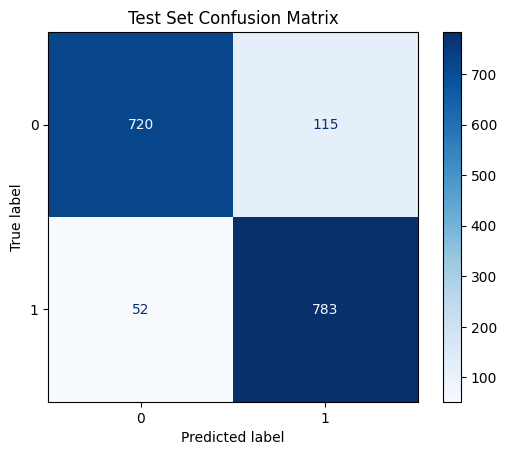

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Load model if this cell is executed before the model-loading cell
if "loaded_model" not in globals():
    loaded_model = load_gnn_model(
        model_class=GCN,
        node_features_dim=4,
        hidden_channels=hidden_channels,
        num_classes=num_classes,
        model_path=str(model_save_path),
        device=device_str,
    ).to(device)

loaded_model.eval()

y_true_test = []
y_pred_test = []
skipped = 0

with torch.no_grad():
    for smi, y_true_i in zip(list(split_obj["test_smiles"]), list(split_obj["test_labels"])):
        g_i = nx_graph_to_pyg_data(smiles_to_nx_graph(smi), label=int(y_true_i))
        if g_i is None:
            skipped += 1
            continue

        g_i = g_i.to(device)
        batch_i = torch.zeros(g_i.x.shape[0], dtype=torch.int64, device=device)
        logits_i = loaded_model(g_i.x, g_i.edge_index, batch=batch_i)
        y_pred_i = int(logits_i.argmax(dim=1).item())

        y_true_test.append(int(y_true_i))
        y_pred_test.append(y_pred_i)

labels = list(range(num_classes))
cm = confusion_matrix(y_true_test, y_pred_test, labels=labels)

print(f"Evaluated test samples: {len(y_true_test)} (skipped: {skipped})")
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test Set Confusion Matrix")
plt.show()

In [4]:
# Ensure model and graph tensors are on the same device
loaded_model = loaded_model.to(device)

# Pick a correctly predicted sample from class 1 (prefer test split)
loaded_model.eval()

sample_smiles, sample_graph = None, None
search_pools = [
    (split_obj["test_smiles"], split_obj["test_labels"], "test"),
    (split_obj["train_smiles"], split_obj["train_labels"], "train"),  # fallback
]

with torch.no_grad():
    for smiles_arr, labels_arr, split_name in search_pools:
        for smi, y_true in zip(list(smiles_arr), list(labels_arr)):
            if int(y_true) != 1:
                continue

            g = nx_graph_to_pyg_data(smiles_to_nx_graph(smi), label=int(y_true))
            if g is None:
                continue
            g = g.to(device)

            batch_tmp = torch.zeros(g.x.shape[0], dtype=torch.int64, device=device)
            logits = loaded_model(g.x, g.edge_index, batch=batch_tmp)
            y_pred = int(logits.argmax(dim=1).item())

            if y_pred == 1:
                sample_smiles, sample_graph = smi, g
                print(f"Selected class-1 correct sample from {split_name} split.")
                break
        if sample_graph is not None:
            break

assert sample_graph is not None, "Could not find a correctly predicted sample from class 1"

explainer = Edgeshaper(
    model=loaded_model,
    x=sample_graph.x,
    edge_index=sample_graph.edge_index,
    edge_weight=None,
    device=device_str,
)

with torch.no_grad():
    batch = torch.zeros(sample_graph.x.shape[0], dtype=torch.int64, device=device)
    pred_logits = loaded_model(sample_graph.x, sample_graph.edge_index, batch=batch)
    target_class = int(pred_logits.argmax(dim=1).item())

phi_edges = explainer.explain_batch(
    M=100,
    target_class=target_class,
    batch_size=100,
    seed=42,
    progress_bar=True,
)

orig_prob = explainer.compute_original_predicted_probability()
pp_set, infidelity = explainer.compute_pertinent_positive_set()
mk_set, fidelity = explainer.compute_minimal_top_k_set()
trust = explainer.compute_trustworthiness()

print('Target class:', target_class)
print('Num edges explained:', len(phi_edges))
print('Original predicted prob:', round(orig_prob, 6))
print('Fidelity+ :', round(fidelity, 6))
print('Infidelity:', round(infidelity, 6))
print('Trustworthiness:', round(trust, 6))
print('Pertinent positive edges:', pp_set.shape[1])
print('Minimal top-k edges:', mk_set.shape[1])

Selected class-1 correct sample from test split.


  0%|          | 0/82 [00:00<?, ?it/s]

C:\Repositories\AI-Agent-for-Compound-Prediction-and-Explainability\src\chemagent\explainability\edgeshaper.py:469: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  E_z_mask = torch.tensor([rng.binomial(1, P, num_edges) for _ in range(batch_size)], dtype=torch.int32).flatten()


Target class: 1
Num edges explained: 82
Original predicted prob: 0.989411
Fidelity+ : 0.67706
Infidelity: 0.481205
Trustworthiness: 0.587455
Pertinent positive edges: 16
Minimal top-k edges: 4


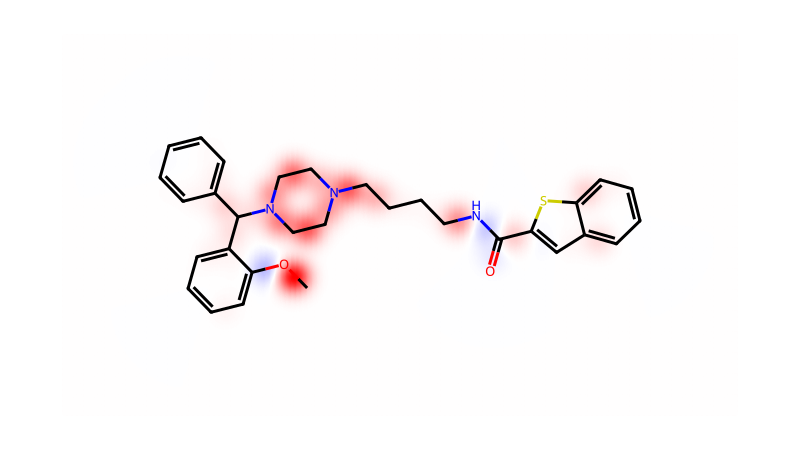

Visualization path: OK


<Figure size 640x480 with 0 Axes>

In [5]:
# Optional visualization check (requires edgeshaper_viz_utils dependencies).
try:
    img_expl, _, _ = explainer.visualize_molecule_explanations(
        smiles=sample_smiles,
        save_path=None,
        pertinent_positive=False,
        minimal_top_k=False,
    )
    display(img_expl)
    print('Visualization path: OK')
except Exception as exc:
    print('Visualization skipped:', type(exc).__name__, '-', exc)

In [6]:
# Minimal assertions for a quick regression smoke test
assert model_save_path.exists(), 'Model file was not saved'
assert isinstance(phi_edges, list) and len(phi_edges) == sample_graph.edge_index.shape[1]
assert isinstance(orig_prob, (int, float))
assert 0.0 <= float(orig_prob) <= 1.0
assert isinstance(fidelity, (int, float))
assert isinstance(infidelity, (int, float))
assert isinstance(trust, (int, float))
print('End-to-end GNN + EdgeSHAPer smoke test passed.')

End-to-end GNN + EdgeSHAPer smoke test passed.
